In [1]:
#Necessary imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [13]:
#Reading csv file and gettinng an insight on the dataset
df = pd.read_csv("loan_approval_data.csv")

#To check the first 10 rows of the dataset as a samole 
df.head()

#To get analytis for each columns on average, mean, count and etc...(.T is used to transpose)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,58645.0,29322.000000,16929.497605,0.00,14661.00,29322.00,43983.00,58644.00
age,58639.0,27.550913,6.033217,20.00,23.00,26.00,30.00,123.00
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.677526,3.036034,-11.14,7.88,10.75,12.99,23.22
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58645.0,69754.717828,61750.913820,-2426900.00,38003.00,62392.00,92716.00,2638778.00


In [14]:
#Drop the id commonly for both datasets
df = df.drop(columns=['id'])

#Removing the invalid values detected through df.describe()
df = df[
    (df['age'] <= 100) &
    (df['loan_interest_rate'] > 0) &
    (df['max_allowed_loan'] >= 0)
]

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,58623.0,27.548675,6.020473,20.00,23.00,26.00,30.00,84.00
income,58623.0,64051.056548,37933.150957,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58623.0,4.703478,4.004783,0.00,2.00,4.00,7.00,150.00
loan_amount,58623.0,9216.844106,5563.195157,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58623.0,10.677855,3.034664,5.42,7.88,10.75,12.99,23.22
loan_income_ratio,58623.0,0.159231,0.091698,0.00,0.09,0.14,0.21,0.83
credit_history_length,58623.0,5.813452,4.029737,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58623.0,0.142384,0.349447,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58623.0,69801.932313,60880.044918,0.00,38030.50,62392.00,92715.00,2638778.00


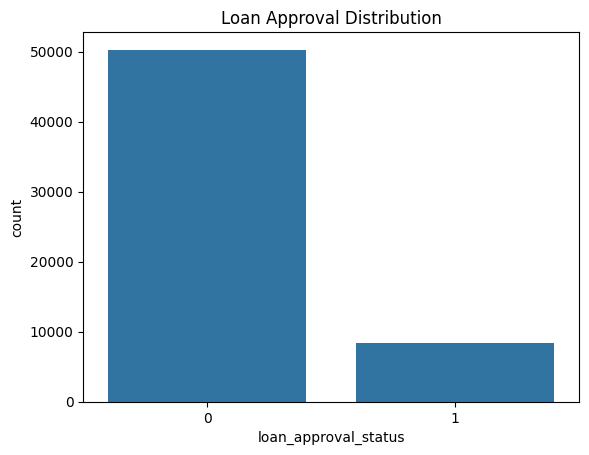

In [16]:
#To check the class distribution between the two values

sns.countplot(x='loan_approval_status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

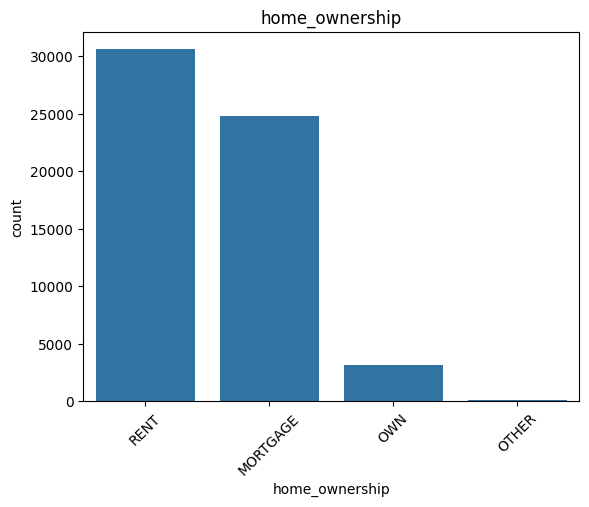

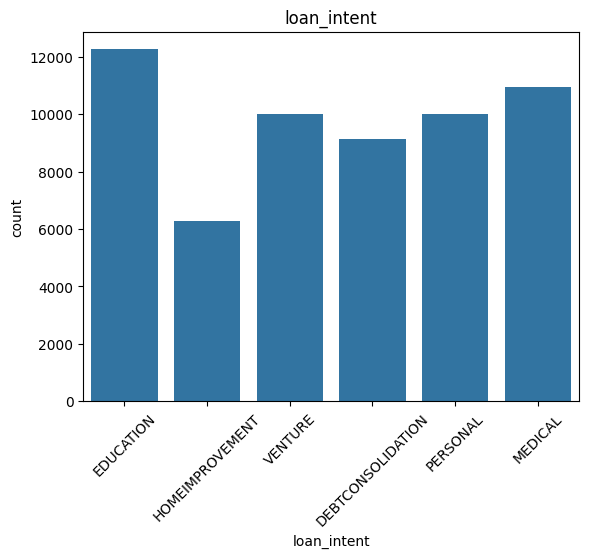

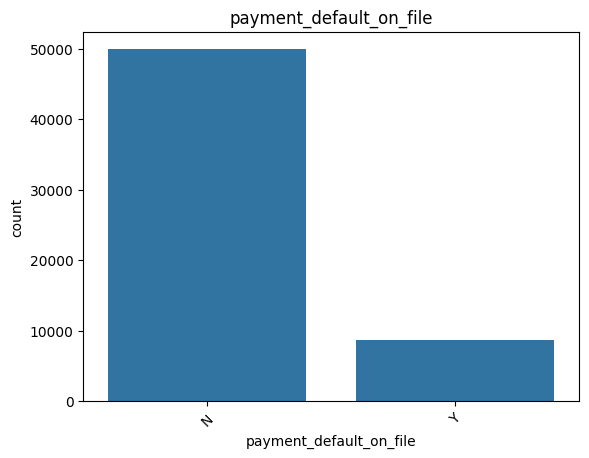

In [19]:
#To see the distribution among categorical values
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

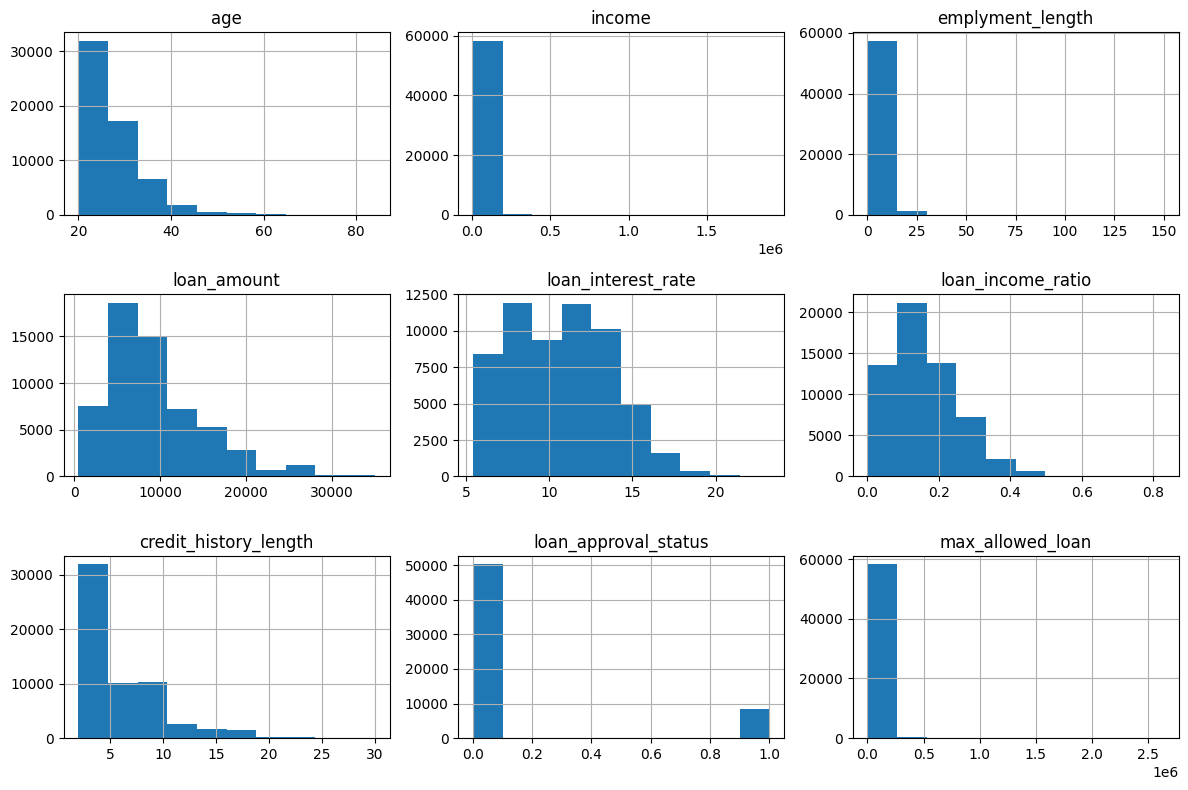

In [23]:
#To see the distribution among numerical values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [29]:
#Check if there are any missing values in the dataset
df.isnull().sum()

age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    5
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

In [30]:
# Calculate the mode (most frequent value)
mode_val = df['payment_default_on_file'].mode()[0]

# Fill the 5 missing spots
df['payment_default_on_file'] = df['payment_default_on_file'].fillna(mode_val)